In [153]:
from pathlib import Path
import json
import configparser

# pip install slicerio
import slicerio.server

# packages for 3d
#   # for OCT 3D stuff and using in jupyter
#   - trame-jupyter-extension
#   - trame
#   - trame-vtk
#   - trame-vuetify
#   - ipywidgets
import numpy as np

import pyvista as pv
from PIL import Image

from zipfile import ZipFile
import xml.etree.ElementTree as ET


In [70]:
class GeeElem(object):
    """Wrapper around an ElementTree element. a['foo'] gets the
       attribute foo, a.foo gets the first subelement foo."""
    def __init__(self, elem):
        self.etElem = elem

    def __getitem__(self, name):
        res = self._getattr(name)
        if res is None:
            raise(AttributeError, "No attribute named '%s'" % name)
        return res

    def __getattr__(self, name):
        res = self._getelem(name)
        if res is None:
            raise(IndexError, "No element named '%s'" % name)
        return res

    def _getelem(self, name):
        res = self.etElem.find(name)
        if res is None:
            return None
        return GeeElem(res)

    def _getattr(self, name):
        return self.etElem.get(name)

class GeeTree(object):
    "Wrapper around an ElementTree."
    def __init__(self, fname):
        self.doc = ET.parse(fname)

    def __getattr__(self, name):
        if self.doc.getroot().tag != name:
            raise(IndexError, "No element named '%s'" % name)
        return GeeElem(self.doc.getroot())

    def getroot(self):
        return self.doc.getroot()

In [5]:
file_vtk = Path(r'C:\Temp\20250325_v2_test_DUMMY_0008_Mode3D.vtk');
file_camimg = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport\20250325_v2_prep\20250325_v2_test_DUMMY_0008_Mode3D_VideoImage.png')
file_settings_ini = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport\20250325_v2_prep\20250325_v2_test_DUMMY_0009_Mode3D.ini')
file_oct = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport\20250325_v2_prep\20250325_v2_test_DUMMY_0009_Mode3D.oct')


Loading VTK volume 20250325_v2_test_DUMMY_0008_Mode3D.vtk
ImageData (0x1d24da36020)
  N Cells:      305775723
  N Points:     307200000
  X Bounds:     0.000e+00, 2.222e+00
  Y Bounds:     0.000e+00, 4.990e+00
  Z Bounds:     0.000e+00, 5.990e+00
  Dimensions:   1024, 500, 600
  Spacing:      2.172e-03, 1.000e-02, 1.000e-02
  N Arrays:     1
Loading camera image 20250325_v2_test_DUMMY_0008_Mode3D_VideoImage.png


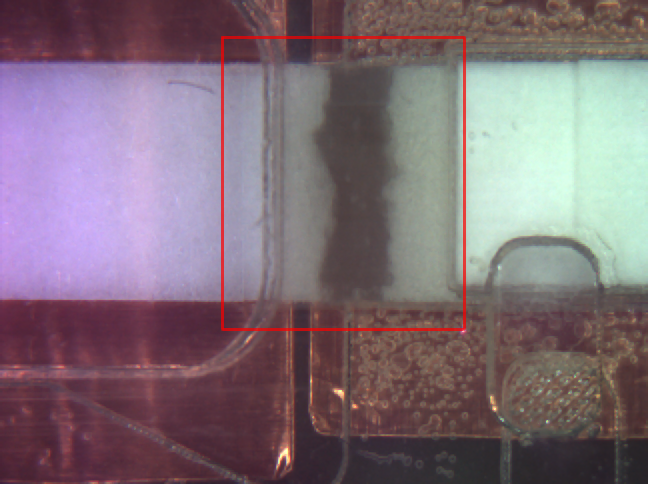

In [7]:
print('Loading VTK volume',file_vtk.name);
vol = pv.read(file_vtk);
print(vol)

print('Loading camera image',file_camimg.name);
#vol = pv.read(file_vtk);
img = Image.open(file_camimg);
img


In [4]:
cam_sz_x,cam_sz_y = img.size
scan_ini_CenterX = 0.403438812717808; # from 20250325_v2_test_DUMMY_0009_Mode3D.ini
scan_ini_CenterY = 1.2;

# Read Metadata From Thorlabs .oct File

In [ ]:
# per thorlabs documentation, .oct files are just .zip files
zip_file_path = file_oct;
#file_name_in_zip = 'my_file.txt'

with ZipFile(zip_file_path, 'r') as zf:
    for zf_file in zf.filelist:
        print(zf_file)
    
    # open and read Probe.ini file
    with zf.open('data/Probe.ini') as file:
        content = file.read().decode('utf-8')
        configprobe = configparser.ConfigParser();
        configprobe.read_string('[probe]\n'+content)
        cfg_oct_probe = {k:dict(v) for k,v in configprobe.items()};
        cfg_oct_probe = cfg_oct_probe['probe'];

    # open and read Header.xml file
    with zf.open('Header.xml') as file:
        cfg_oct_xml = GeeTree(file);

    # open and parse the data/Intensity.data into a PyVista / VTK Image Data volume
    intensity_volume_name_in_zip = 'data\\Intensity.data';
    vol_img_attribs = [e.attrib for e in cfg_oct_xml.Ocity.DataFiles.etElem if e.text==intensity_volume_name_in_zip][0];
    vol_dimensions = (
        # int(cfg_oct_xml.Ocity.Image.SizePixel.SizeZ.etElem.text),
        # int(cfg_oct_xml.Ocity.Image.SizePixel.SizeX.etElem.text),
        # int(cfg_oct_xml.Ocity.Image.SizePixel.SizeY.etElem.text),
        int(cfg_oct_xml.Ocity.Image.SizePixel.etElem[0].text),
        int(cfg_oct_xml.Ocity.Image.SizePixel.etElem[1].text),
        int(cfg_oct_xml.Ocity.Image.SizePixel.etElem[2].text),
    );
    vol_spacing_mm = (
        # int(cfg_oct_xml.Ocity.Image.SizePixel.SizeZ.etElem.text),
        # int(cfg_oct_xml.Ocity.Image.SizePixel.SizeX.etElem.text),
        # int(cfg_oct_xml.Ocity.Image.SizePixel.SizeY.etElem.text),
        float(cfg_oct_xml.Ocity.Image.PixelSpacing.etElem[0].text),
        float(cfg_oct_xml.Ocity.Image.PixelSpacing.etElem[1].text),
        float(cfg_oct_xml.Ocity.Image.PixelSpacing.etElem[2].text),
    );
    # open and read Header.xml file
    with zf.open('data/Intensity.data','r') as file:
        scalars = np.frombuffer(file.read(),dtype=np.float32)
print('Image Dims:{:s} PixelSpacing[mm]:{:s}'.format(str(vol_dimensions),str(vol_spacing_mm)))
newvol = pv.ImageData(dimensions=vol_dimensions,spacing=vol_spacing_mm);
newvol['octintensity'] = scalars;

<ZipInfo filename='data/Intensity.data' filemode='-rw-rw-rw-' file_size=307200000>
<ZipInfo filename='data/PreviewImage.data' compress_type=deflate filemode='-rw-rw-rw-' file_size=1228800 compress_size=37261>
<ZipInfo filename='data/VideoImage.data' compress_type=deflate filemode='-rw-rw-rw-' file_size=1254528 compress_size=761559>
<ZipInfo filename='data/Probe.ini' filemode='-rw-rw-rw-' file_size=1792>
<ZipInfo filename='Header.xml' filemode='-rw-rw-rw-' file_size=5856>


In [156]:
file

<zipfile.ZipExtFile [closed]>

In [160]:
newvol['octintensity'] = scalars;

In [ ]:
vol_img_attribs

{'Type': 'Real',
 'SizeZ': '1024',
 'SizeX': '250',
 'SizeY': '300',
 'RangeZ': '2.2239999999999998',
 'RangeX': '5',
 'RangeY': '6',
 'BytesPerPixel': '4'}